# Görev 1: Doğal Dil İşleme ile Ürün Yorumları Duygu Analizi

Bu notebook, IMDB Dataset.csv veri seti üzerinde duygu analizi gerçekleştirir. Adımlar:
- Metin ön işleme :noktalama temizleme, stop-word atma, tokenization, lemmatization
- Model kurulumu :TF-IDF vektörizasyon, SVM sınıflandırma
- İş kararı :negatif yorumlardan en çok şikayet edilen 5 anahtar kelime tespiti

In [4]:
# Gerekli kütüphaneleri içe aktar
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# NLTK verilerini indir (gerekirse)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Veri setini yükle
df = pd.read_csv('IMDB Dataset.csv')
print("Veri seti boyutu:", df.shape)
print("Sütunlar:", df.columns.tolist())
print(df.head())

Veri seti boyutu: (50000, 2)
Sütunlar: ['review', 'sentiment']
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


## Metin Ön İşleme

Bu bölümde:
- Noktalama işaretlerini temizleme
- Stop-word'leri atma
- Tokenization
- Lemmatization

In [5]:
# Ön işleme fonksiyonu
def preprocess_text(text):
    # Küçük harfe çevir
    text = text.lower()
    # HTML etiketlerini kaldır
    text = re.sub(r'<.*?>', '', text)
    # Noktalama işaretlerini kaldır
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Stop-word'leri kaldır
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Veri setine uygula (küçük örnek için ilk 1000 satır)
df_small = df.head(1000).copy()
df_small['cleaned_review'] = df_small['review'].apply(preprocess_text)
print("Ön işleme tamamlandı. Örnek:")
print(df_small[['review', 'cleaned_review']].head())

Ön işleme tamamlandı. Örnek:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mentioned watching 1 oz episode y...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


## Model Kurulumu

Bu bölümde:
- TF-IDF vektörizasyonu
- SVM model eğitimi ve değerlendirmesi

In [6]:
# Eğitim ve test verilerini ayır
X = df_small['cleaned_review']
y = df_small['sentiment'].map({'positive': 1, 'negative': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF vektörizasyonu
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# SVM model eğitimi
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Tahmin ve değerlendirme
y_pred = svm_model.predict(X_test_tfidf)
print("Doğruluk:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Doğruluk: 0.855
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       104
           1       0.85      0.85      0.85        96

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.86      0.85      0.86       200



## İş Kararı: Anahtar Kelime Tespiti

Negatif yorumlardan en çok şikayet edilen 5 anahtar kelimeyi tespit et.

En çok şikayet edilen 5 anahtar kelime:
movie: 1131
film: 850
one: 478
like: 428
even: 320


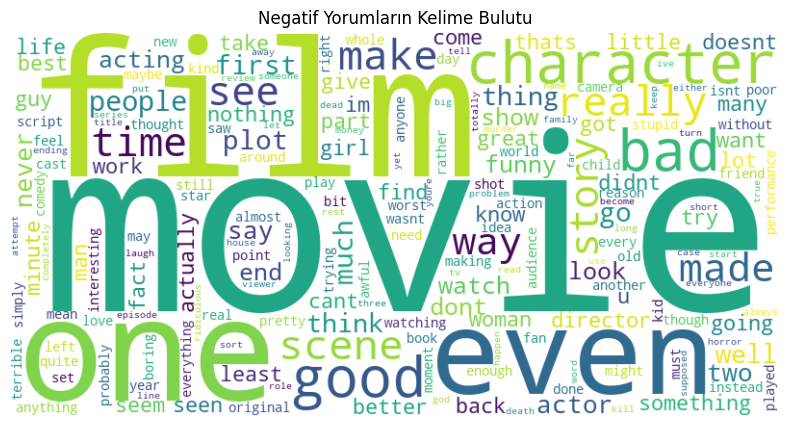

In [7]:
# Negatif yorumları al
negative_reviews = df_small[df_small['sentiment'] == 'negative']['cleaned_review']

# Tüm kelimeleri topla
all_words = ' '.join(negative_reviews).split()
word_freq = Counter(all_words)

# En çok geçen 5 kelime
top_5_words = word_freq.most_common(5)
print("En çok şikayet edilen 5 anahtar kelime:")
for word, freq in top_5_words:
    print(f"{word}: {freq}")

# Word cloud görselleştirme
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negatif Yorumların Kelime Bulutu')
plt.show()